# Regression Pipeline

The target: `recommended_upgrade_cost_est`


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import os
import joblib
from pathlib import Path
import shap
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from dotenv import load_dotenv
from openai import OpenAI

shap.initjs()

In [2]:
candidate_paths = [
    Path("../preprocessing/data/cleaned_laptop_data.csv")
]

cleaned_path = None
for p in candidate_paths:
    if p.exists():
        cleaned_path = p
        break

if cleaned_path is None:
    raise FileNotFoundError("Could not find cleaned_laptop_data.csv. Run the shared data prep notebook first.")

print("Using cleaned file:", cleaned_path)
data = pd.read_csv(cleaned_path)
print("Shape:", data.shape)
data.head()

Using cleaned file: ..\preprocessing\data\cleaned_laptop_data.csv
Shape: (19545, 53)


,type_name,user_profile,budget_class,upgrade_first,gain_class,price,recommended_upgrade_cost_est,inches,weight_kg,opsys,...,gpu_urgency_score,performance_score,ram_gap_ratio,storage_gap_ratio,gpu_gap_ratio,upgrade_pressure,total_urgency,price_per_performance,storage_capacity_score,storage_speed_score
0,Ultrabook,student,low,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.0,12.150286,0.0,0.498054,0.0,0.124514,0.113667,5427.918441,128,128.0
1,Ultrabook,student,medium,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.0,12.150286,0.0,0.498054,0.0,0.124514,0.113667,5427.918441,128,128.0
2,Ultrabook,student,high,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.0,12.150286,0.0,0.498054,0.0,0.124514,0.113667,5427.918441,128,128.0
3,Ultrabook,office,low,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.0,12.150286,0.0,0.498054,0.0,0.124514,0.113667,5427.918441,128,128.0
4,Ultrabook,office,medium,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.0,12.150286,0.0,0.498054,0.0,0.124514,0.113667,5427.918441,128,128.0


In [3]:
regression_numeric_features = [
    "price",
    "ram_gb",
    "ssd_gb",
    "hdd_gb",
    "flash_gb",
    "hybrid_gb",
    "total_storage_gb",
    "cpu_score",
    "gpu_score",
    "target_ram_gb",
    "target_storage_gb",
    "target_gpu_score",
    "ram_gap_gb",
    "storage_gap_gb",
    "gpu_gap_score",
    "performance_score",
    "upgrade_pressure",
    "total_urgency",
    "price_per_performance",
    "storage_capacity_score",
    "storage_speed_score"
]

regression_categorical_features = [
    "type_name",
    "user_profile",
    "budget_class",
    "cpu_brand",
    "gpu_brand"
]

regression_binary_features = [
    "has_ssd",
    "has_hdd",
    "is_integrated_gpu"
]

regression_features = (
    regression_numeric_features +
    regression_categorical_features +
    regression_binary_features
)

X_reg = data[regression_features].copy()
y_reg = data["recommended_upgrade_cost_est"].copy()

print("Feature matrix shape:", X_reg.shape)
print("Target shape:", y_reg.shape)

Feature matrix shape: (19545, 29)
Target shape: (19545,)


In [4]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_reg_train.shape)
print("Test shape :", X_reg_test.shape)

Train shape: (15636, 29)
Test shape : (3909, 29)


In [5]:
reg_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), regression_numeric_features),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), regression_categorical_features),

    ("bin", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]), regression_binary_features)
])

X_reg_train_p = reg_preprocessor.fit_transform(X_reg_train)
X_reg_test_p = reg_preprocessor.transform(X_reg_test)

print("Processed train shape:", X_reg_train_p.shape)
print("Processed test shape :", X_reg_test_p.shape)

Processed train shape: (15636, 45)
Processed test shape : (3909, 45)


In [6]:
reg_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    max_features="sqrt",
    n_jobs=-1
)

reg_lr = LinearRegression()

reg_rf.fit(X_reg_train_p, y_reg_train)
reg_lr.fit(X_reg_train_p, y_reg_train)
print("Both regression models trained.")

Both regression models trained.


In [7]:
def evaluate_regressor(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"=== {name} ===")
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R2  :", round(r2, 4))

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

rf_results = evaluate_regressor(reg_rf, X_reg_test_p, y_reg_test, "Random Forest Regressor")
lr_results = evaluate_regressor(reg_lr, X_reg_test_p, y_reg_test, "Linear Regression")

=== Random Forest Regressor ===
MAE : 3.6656
RMSE: 19.3183
R2  : 0.9793
=== Linear Regression ===
MAE : 55.3038
RMSE: 79.7492
R2  : 0.6472


In [8]:
results_df = pd.DataFrame([rf_results, lr_results]).sort_values(by=["R2", "RMSE"], ascending=[False, True])
display(results_df)

best_regressor_name = results_df.iloc[0]["Model"]
best_regressor = reg_rf if best_regressor_name == "Random Forest Regressor" else reg_lr

print("Selected final regression model:", best_regressor_name)

,Model,MAE,RMSE,R2
0,Random Forest Regressor,3.665647,19.318343,0.979299
1,Linear Regression,55.303829,79.749206,0.647221


Selected final regression model: Random Forest Regressor


In [ ]:
ohe = reg_preprocessor.named_transformers_["cat"].named_steps["onehot"]
reg_processed_feature_names = (
    regression_numeric_features +
    list(ohe.get_feature_names_out(regression_categorical_features)) +
    regression_binary_features
)

print("Processed feature count:", len(reg_processed_feature_names))
print(reg_processed_feature_names[:20])

Processed feature count: 45
['price', 'ram_gb', 'ssd_gb', 'hdd_gb', 'flash_gb', 'hybrid_gb', 'total_storage_gb', 'cpu_score', 'gpu_score', 'target_ram_gb', 'target_storage_gb', 'target_gpu_score', 'ram_gap_gb', 'storage_gap_gb', 'gpu_gap_score', 'performance_score', 'upgrade_pressure', 'total_urgency', 'price_per_performance', 'storage_capacity_score']


In [10]:
# Save artifacts
artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)

joblib.dump(reg_preprocessor, artifact_dir / "reg_preprocessor.pkl")
joblib.dump(best_regressor, artifact_dir / "best_regressor_model.pkl")
joblib.dump(regression_features, artifact_dir / "regression_features.pkl")
joblib.dump(reg_processed_feature_names, artifact_dir / "reg_processed_feature_names.pkl")

print("Regression artifacts saved in:", artifact_dir.resolve())

Regression artifacts saved in: C:\Users\ahmad\Desktop\uni\3rd year\2nd sem\applied\laptop_decision_portal\notebooks\artifacts


In [11]:
artifact_dir = Path("../notebooks/artifacts")

model_for_shap = joblib.load(artifact_dir / "best_regressor_model.pkl")
feature_names = joblib.load(artifact_dir / "reg_processed_feature_names.pkl")

print(type(model_for_shap))
print("Number of processed features:", len(feature_names))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
Number of processed features: 45


In [12]:
X_sample = X_reg_test_p

if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()

print("X_sample shape:", X_sample.shape)
print("Feature names:", len(feature_names))

X_sample shape: (3909, 45)
Feature names: 45


In [13]:
explainer = shap.TreeExplainer(model_for_shap)
shap_values = explainer.shap_values(X_sample)

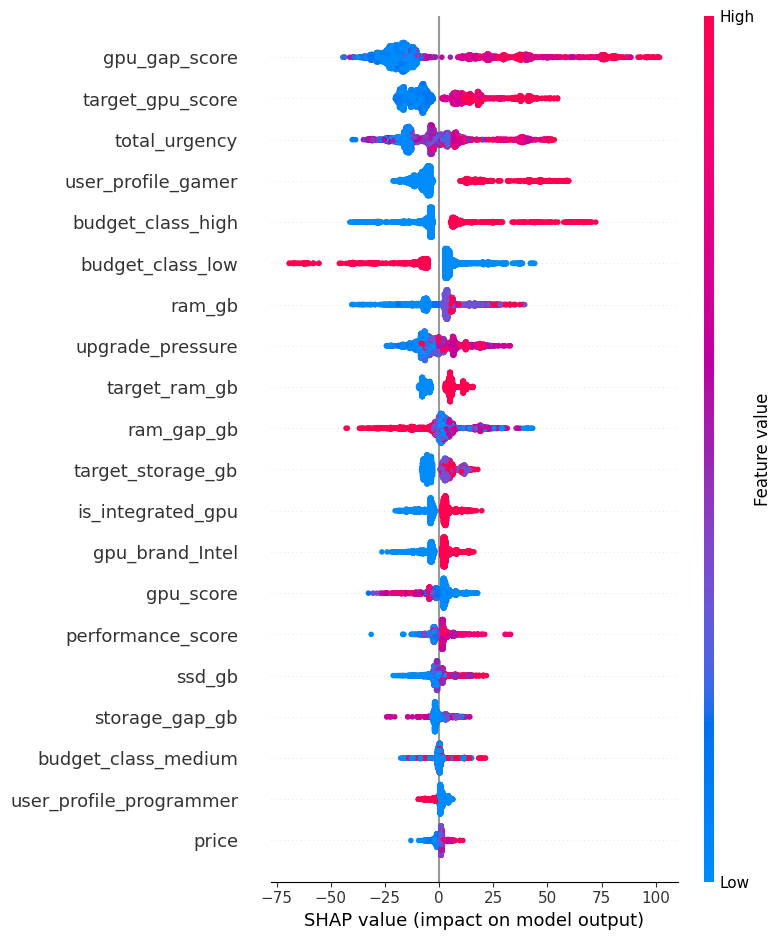

In [14]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names
)

In [15]:
i = 0

true_value = y_reg_test.iloc[i]
pred_value = model_for_shap.predict(X_reg_test_p[i:i+1])[0]

print("True value:", true_value)
print("Predicted value:", pred_value)

True value: 0.0
Predicted value: 0.0


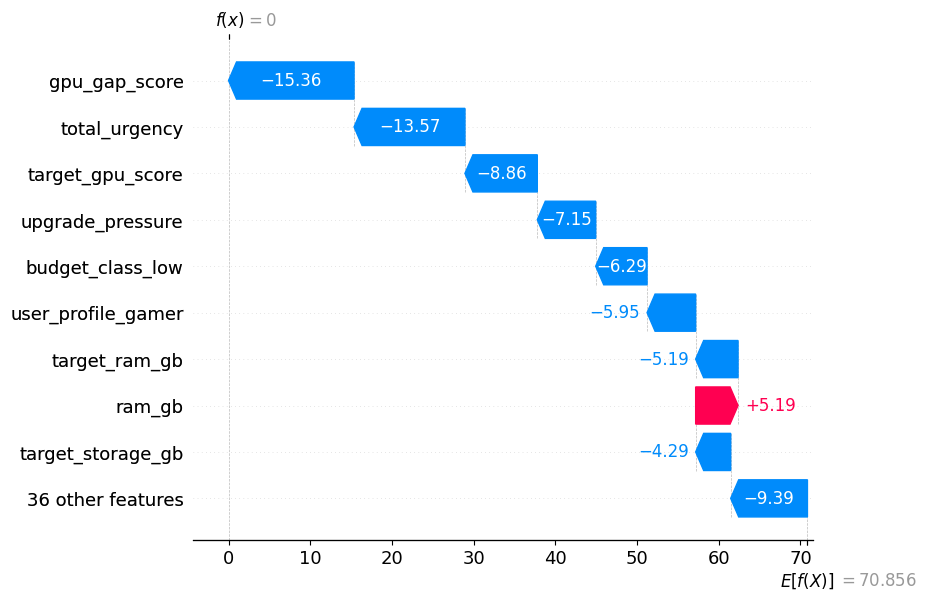

In [16]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[0],
    shap_values[i],
    feature_names=feature_names
) 

In [17]:
from lime.lime_tabular import LimeTabularExplainer

X_train_lime = X_reg_train_p.toarray() if hasattr(X_reg_train_p, "toarray") else X_reg_train_p
X_test_lime = X_reg_test_p.toarray() if hasattr(X_reg_test_p, "toarray") else X_reg_test_p

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=feature_names,
    mode="regression"
)

In [18]:
i = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_lime[i],
    predict_fn=model_for_shap.predict,
    num_features=10
)

In [19]:
lime_exp.show_in_notebook(show_table=True)

In [20]:
print("True value:", y_reg_test.iloc[i])
print("Predicted value:", model_for_shap.predict(X_reg_test_p[i:i+1])[0])

print("\nTop LIME feature contributions:")
for item in lime_exp.as_list():
    print(item)

True value: 0.0
Predicted value: 0.0

Top LIME feature contributions:
('gpu_gap_score <= -0.75', -34.73232019094025)
('user_profile_gamer <= 0.00', -28.602061056357794)
('total_urgency <= -1.14', -27.985061656494015)
('gpu_brand_Arm <= 0.00', -25.9706320206757)
('target_gpu_score <= -0.79', -25.105483979121367)
('budget_class_high <= 0.00', -24.851941594856182)
('0.00 < budget_class_low <= 1.00', -20.76382242578374)
('cpu_brand_Other <= 0.00', -20.755459110995844)
('hybrid_gb <= -0.10', -16.02986805192264)
('ram_gb > -0.08', 15.222642463366588)


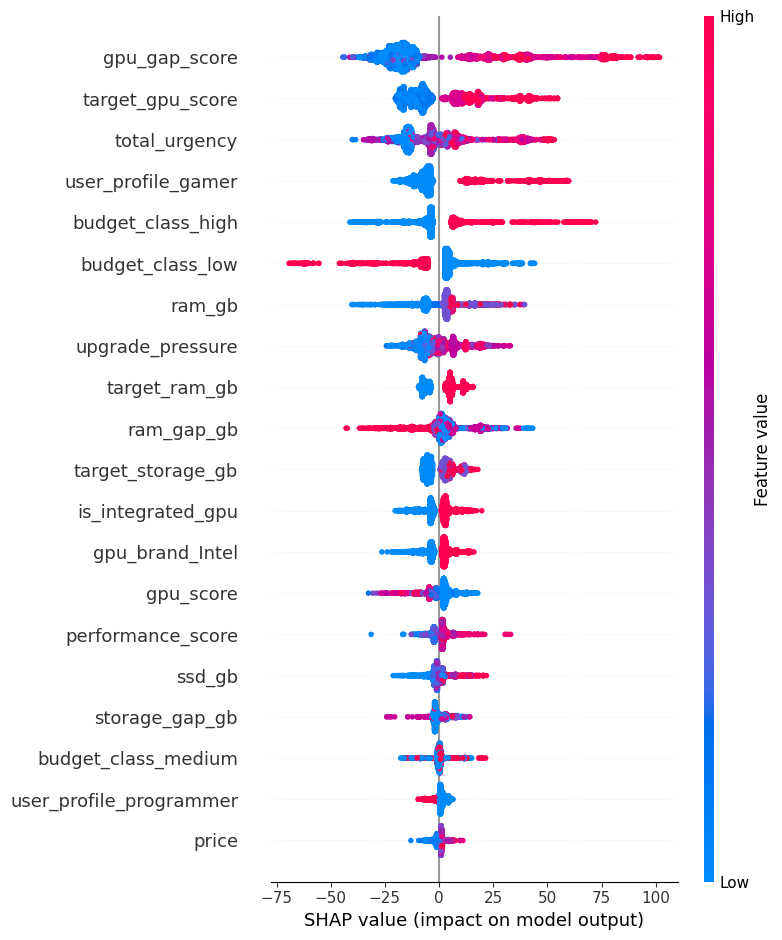

In [21]:

plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.savefig("regression_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
load_dotenv()

client = OpenAI(
    api_key=os.getenv("GROQ_API"),
    base_url="https://api.groq.com/openai/v1"
)



In [23]:
# Pick ONE example
i = 0

# Prediction
pred_value = model_for_shap.predict(X_reg_test_p[i:i+1])[0]
true_value = y_reg_test.iloc[i]

# SHAP (top 5 features)
local_shap = shap_values[i]

top_shap_idx = np.argsort(np.abs(local_shap))[::-1][:5]

top_shap_features = [
    f"{feature_names[idx]}: {round(float(local_shap[idx]), 3)}"
    for idx in top_shap_idx
]

# LIME
lime_points = [
    f"{name}: {round(float(value), 3)}"
    for name, value in lime_exp.as_list()
]

# SIMPLE PROMPT
regression_prompt = f"""
Explain this predicted value simply.

Predicted value: {round(float(pred_value), 2)}

Top reasons:
{top_shap_features}

Also:
{lime_points}

Explain what made the value higher or lower in 3-4 simple lines.
"""

# API CALL
response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[
        {"role": "system", "content": "Explain clearly using only given reasons."},
        {"role": "user", "content": regression_prompt}
    ],
    temperature=0.1,
    max_tokens=120
)

regression_llm_explanation = response.choices[0].message.content

print("\n=== REGRESSION EXPLANATION ===")
print(regression_llm_explanation)


=== REGRESSION EXPLANATION ===
The predicted value is 0.0, indicating a neutral or average outcome. 

Several factors contributed to this result:

- Negative scores from 'gpu_gap_score', 'total_urgency', 'target_gpu_score', 'upgrade_pressure', and 'budget_class_low' pulled the value down.
- Some conditions, such as 'gpu_gap_score <= -0.75' and 'total_urgency <= -1.14', also had a significant negative impact.
- However, a positive score from 'ram_gb > -0.08' slightly offset the negative effects, but it was not
